In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
file_path = "german_credit_data.csv"
df = pd.read_csv(file_path)

In [13]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [19]:
# --- 1. Identify Structure and Data Types ---
print("#### 1. Dataset Structure and Data Types ####")
df.rename(columns = {"Unnamed: 0" : "ID"}, inplace=True)
print("Dataset Head:")
print(df.head())

#### 1. Dataset Structure and Data Types ####
Dataset Head:
   ID  Age     Sex  Job Housing Saving accounts Checking account  \
0   0   67    male    2     own             NaN           little   
1   1   22  female    2     own          little         moderate   
2   2   49    male    1     own          little              NaN   
3   3   45    male    2    free          little           little   
4   4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  


In [20]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID                1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [18]:
print("\nKey Variables Description:")
print(df[
        [
            "ID",
            "Age",
            "Sex",
            "Job",
            "Housing",
            "Saving accounts",
            "Checking account",
            "Credit amount",  # Changed from "Credit Amount"
            "Duration",
            "Purpose",
        ]
    ].describe(include="all")
)


Key Variables Description:
                 ID          Age   Sex          Job Housing Saving accounts  \
count   1000.000000  1000.000000  1000  1000.000000    1000             817   
unique          NaN          NaN     2          NaN       3               4   
top             NaN          NaN  male          NaN     own          little   
freq            NaN          NaN   690          NaN     713             603   
mean     499.500000    35.546000   NaN     1.904000     NaN             NaN   
std      288.819436    11.375469   NaN     0.653614     NaN             NaN   
min        0.000000    19.000000   NaN     0.000000     NaN             NaN   
25%      249.750000    27.000000   NaN     2.000000     NaN             NaN   
50%      499.500000    33.000000   NaN     2.000000     NaN             NaN   
75%      749.250000    42.000000   NaN     2.000000     NaN             NaN   
max      999.000000    75.000000   NaN     3.000000     NaN             NaN   

       Checking account

In [21]:
# --- 2. Check for and Address Missing Values ---
print("\n#### 2. Missing Values Analysis ####")
missing_values_before = df.isnull().sum()
print("Missing values before handling:")
print(missing_values_before[missing_values_before > 0])


#### 2. Missing Values Analysis ####
Missing values before handling:
Saving accounts     183
Checking account    394
dtype: int64


In [22]:
# Address missing values in 'Saving accounts' and 'Checking account'
# Assuming missing values in these columns imply no account, we'll fill them with a specific string.
df["Saving accounts"] = df["Saving accounts"].fillna("no_account")
df["Checking account"] = df["Checking account"].fillna("no_account")

missing_values_after = df.isnull().sum()
print("\nMissing values after handling:")
print(missing_values_after[missing_values_after > 0])


Missing values after handling:
Series([], dtype: int64)


In [ ]:
# --- 3. Detect Outliers ---
print("\n#### 3. Outlier Detection ####")
numerical_cols = [
    "Credit amount",
    "Duration",
    "Age",
]  # Including Age as it's numerical and can have outliers
for col in numerical_cols:
    print(f"\n--- {col} ---")
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Q1 (25th percentile): {Q1}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound for Outliers: {lower_bound}")
    print(f"Upper Bound for Outliers: {upper_bound}")
    print(f"Number of outliers detected: {len(outliers)}")
    if not outliers.empty:
        print("First 5 Outliers (if any):")
        print(outliers[[col]].head())
    else:
        print("No significant outliers detected based on IQR method.")



#### 3. Outlier Detection ####

--- Credit amount ---
Q1 (25th percentile): 1365.5
Q3 (75th percentile): 3972.25
IQR: 2606.75
Lower Bound for Outliers: -2544.625
Upper Bound for Outliers: 7882.375
Number of outliers detected: 72
First 5 Outliers (if any):
    Credit amount
5            9055
17           8072
18          12579
57           9566
63          14421

--- Duration ---
Q1 (25th percentile): 12.0
Q3 (75th percentile): 24.0
IQR: 12.0
Lower Bound for Outliers: -6.0
Upper Bound for Outliers: 42.0
Number of outliers detected: 70
First 5 Outliers (if any):
    Duration
1         48
11        48
29        60
35        45
36        48

--- Age ---
Q1 (25th percentile): 27.0
Q3 (75th percentile): 42.0
IQR: 15.0
Lower Bound for Outliers: 4.5
Upper Bound for Outliers: 64.5
Number of outliers detected: 23
First 5 Outliers (if any):
     Age
0     67
75    66
137   66
163   70
179   65

Dataset audit complete. The `german_credit_data.csv` dataset has been analyzed for structure, data typ

### Phase 2: Exploratory Data Analysis (EDA)

#### 1. Correlation Analysis ####


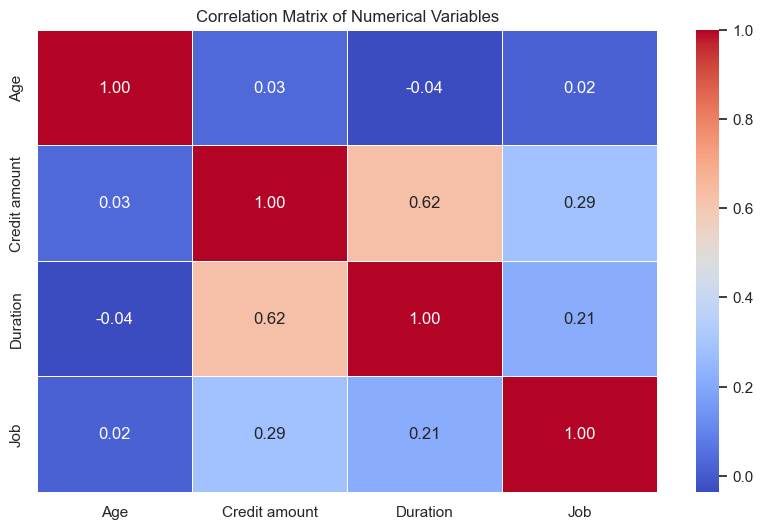

Correlation Matrix:
                    Age  Credit amount  Duration       Job
Age            1.000000       0.032716 -0.036136  0.015673
Credit amount  0.032716       1.000000  0.624984  0.285385
Duration      -0.036136       0.624984  1.000000  0.210910
Job            0.015673       0.285385  0.210910  1.000000

Insight: Look for strong relationships between Credit Amount and Duration.


In [26]:
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# --- 1. Correlation Analysis for Numerical Variables ---
# Based on the lab requirements to perform correlation analysis 
print("#### 1. Correlation Analysis ####")
# Numerical columns identified in the dataset 
# Note: 'Job' is numeric (0-3) but acts as an ordinal category 
numerical_vars = ['Age', 'Credit amount', 'Duration', 'Job']
corr_matrix = df[numerical_vars].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

print("Correlation Matrix:")
print(corr_matrix)
print("\nInsight: Look for strong relationships between Credit Amount and Duration.")


#### 2. Numerical Distributions ####


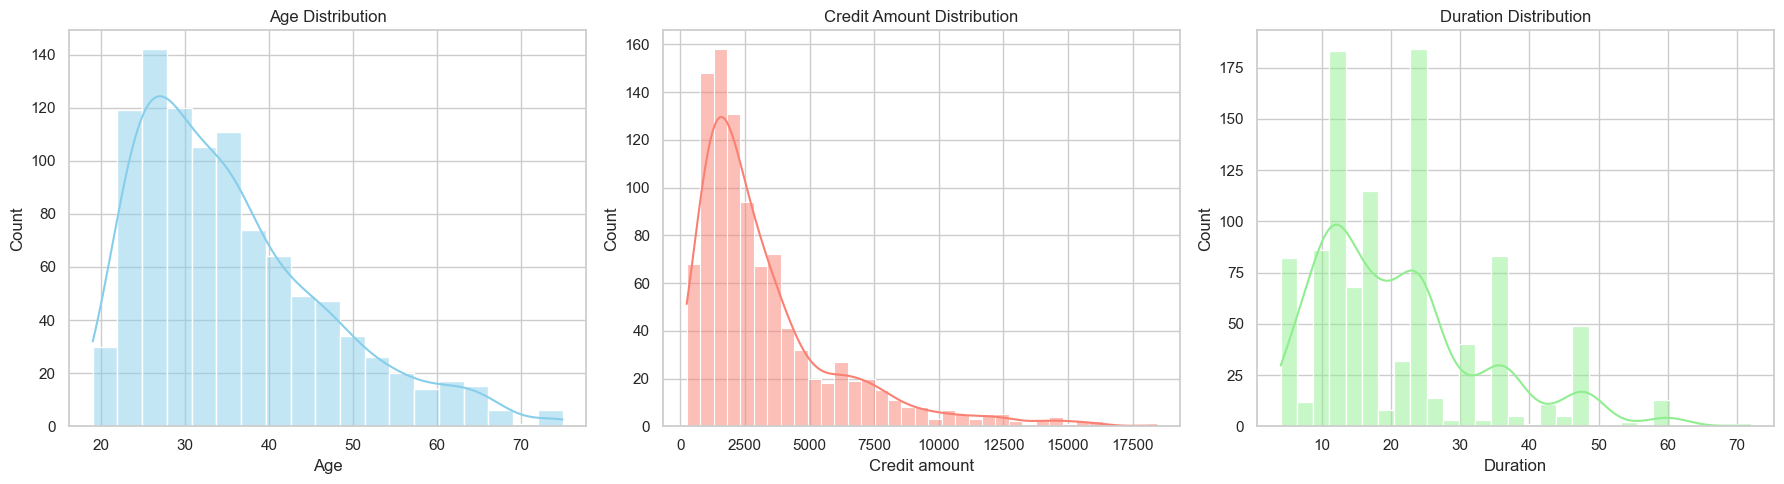

In [27]:
# --- 2. Numerical Variable Distributions ---
# Visualizing the distribution of key KPIs [cite: 37, 38]
print("\n#### 2. Numerical Distributions ####")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(df['Credit amount'], kde=True, ax=axes[1], color='salmon').set_title('Credit Amount Distribution')
sns.histplot(df['Duration'], kde=True, ax=axes[2], color='lightgreen').set_title('Duration Distribution')

plt.tight_layout()
plt.show()


#### 3. Categorical Variable Profiles ####


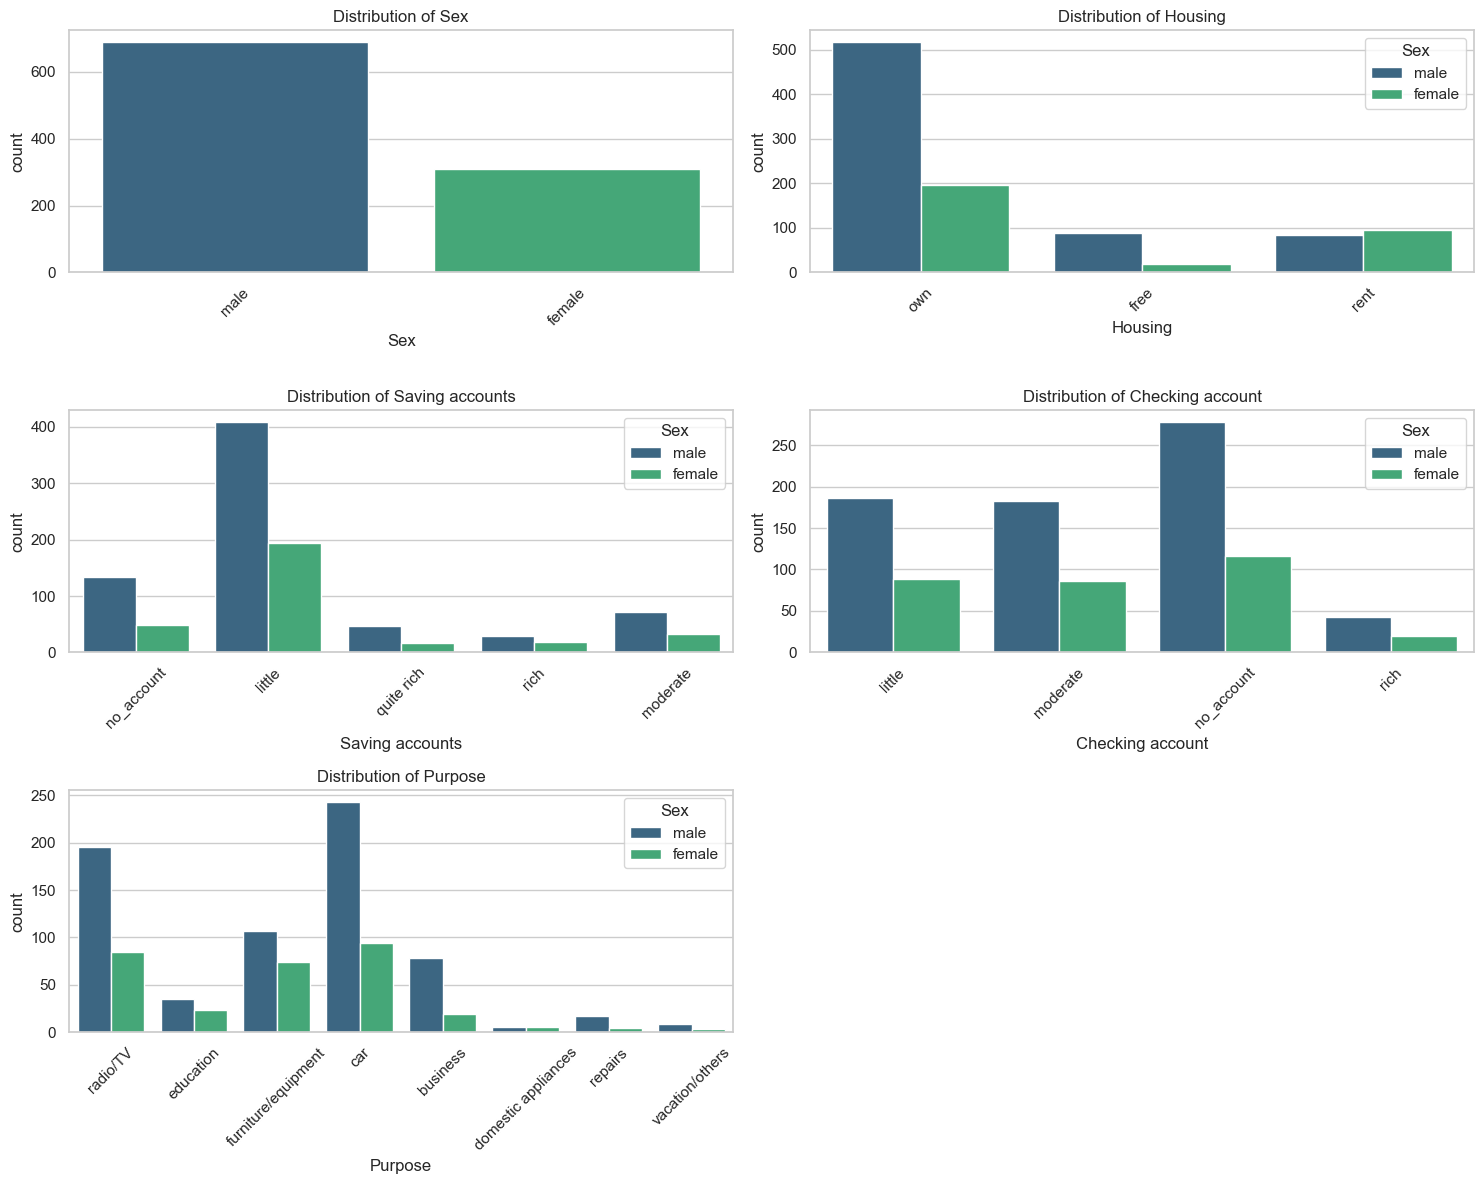

In [28]:
# --- 3. Categorical Variable Analysis ---
# Analyzing categories like 'Purpose' and 'Housing' to understand customer profiles 
print("\n#### 3. Categorical Variable Profiles ####")

categorical_vars = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

plt.figure(figsize=(15, 12))
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=var, hue='Sex', palette='viridis')
    plt.title(f'Distribution of {var}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# --- 4. Mean Values by Categorical Groups ---
# Examining mean values to prepare for future Persona building [cite: 70]
print("\n#### 4. Grouped Profile Analysis (Mean Values) ####")
profile_analysis = df.groupby('Purpose')[['Age', 'Credit amount', 'Duration']].mean()
print("Average metrics by Credit Purpose:")
print(profile_analysis)


#### 4. Grouped Profile Analysis (Mean Values) ####
Average metrics by Credit Purpose:
                           Age  Credit amount   Duration
Purpose                                                 
business             35.484536    4158.041237  26.938144
car                  37.139466    3768.192878  20.813056
domestic appliances  34.250000    1498.000000  16.833333
education            38.288136    2879.203390  19.677966
furniture/equipment  32.458564    3066.988950  19.292818
radio/TV             34.700000    2487.653571  20.046429
repairs              38.545455    2728.090909  19.090909
vacation/others      39.916667    8209.333333  32.333333


### Phase 3: Pre-processing and Clustering 

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# --- 1. Data Pre-processing: Encoding and Normalization ---
print("#### 1. Pre-processing ####")

# Drop 'ID' as it is a unique identifier and doesn't contribute to similarity 
df_clustering = df.drop(columns=['ID'])

# Encode categorical variables into dummy/indicator variables 
# Categorical variables: Sex, Housing, Saving accounts, Checking account, Purpose
df_encoded = pd.get_dummies(df_clustering, columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], drop_first=True)

# Normalize the data 
# Scaling is critical so that 'Credit amount' doesn't dominate smaller scales like 'Age' or 'Job'
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)

print("Data encoded and normalized successfully.")

#### 1. Pre-processing ####
Data encoded and normalized successfully.



#### 2. K-Means: Elbow Method and Silhouette Score ####


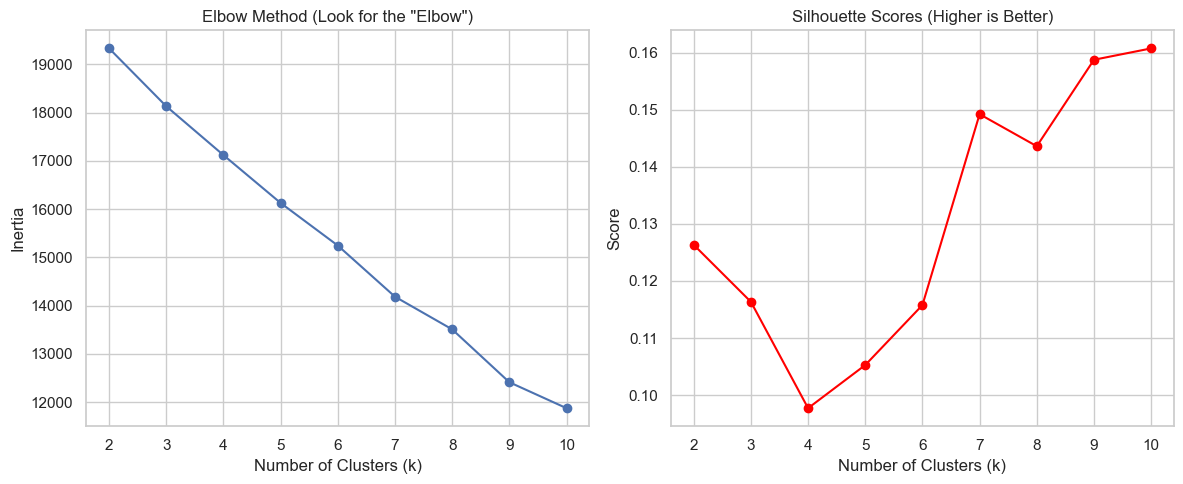

In [33]:
# --- 2. K-Means: Determining Optimal Clusters (k) ---
print("\n#### 2. K-Means: Elbow Method and Silhouette Score ####")

inertia = []
silhouette_pts = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_pts.append(silhouette_score(scaled_features, kmeans.labels_))

# Plotting Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method (Look for the "Elbow")')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_pts, marker='o', color='red')
plt.title('Silhouette Scores (Higher is Better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


#### 3. Hierarchical Clustering (Dendrogram) ####


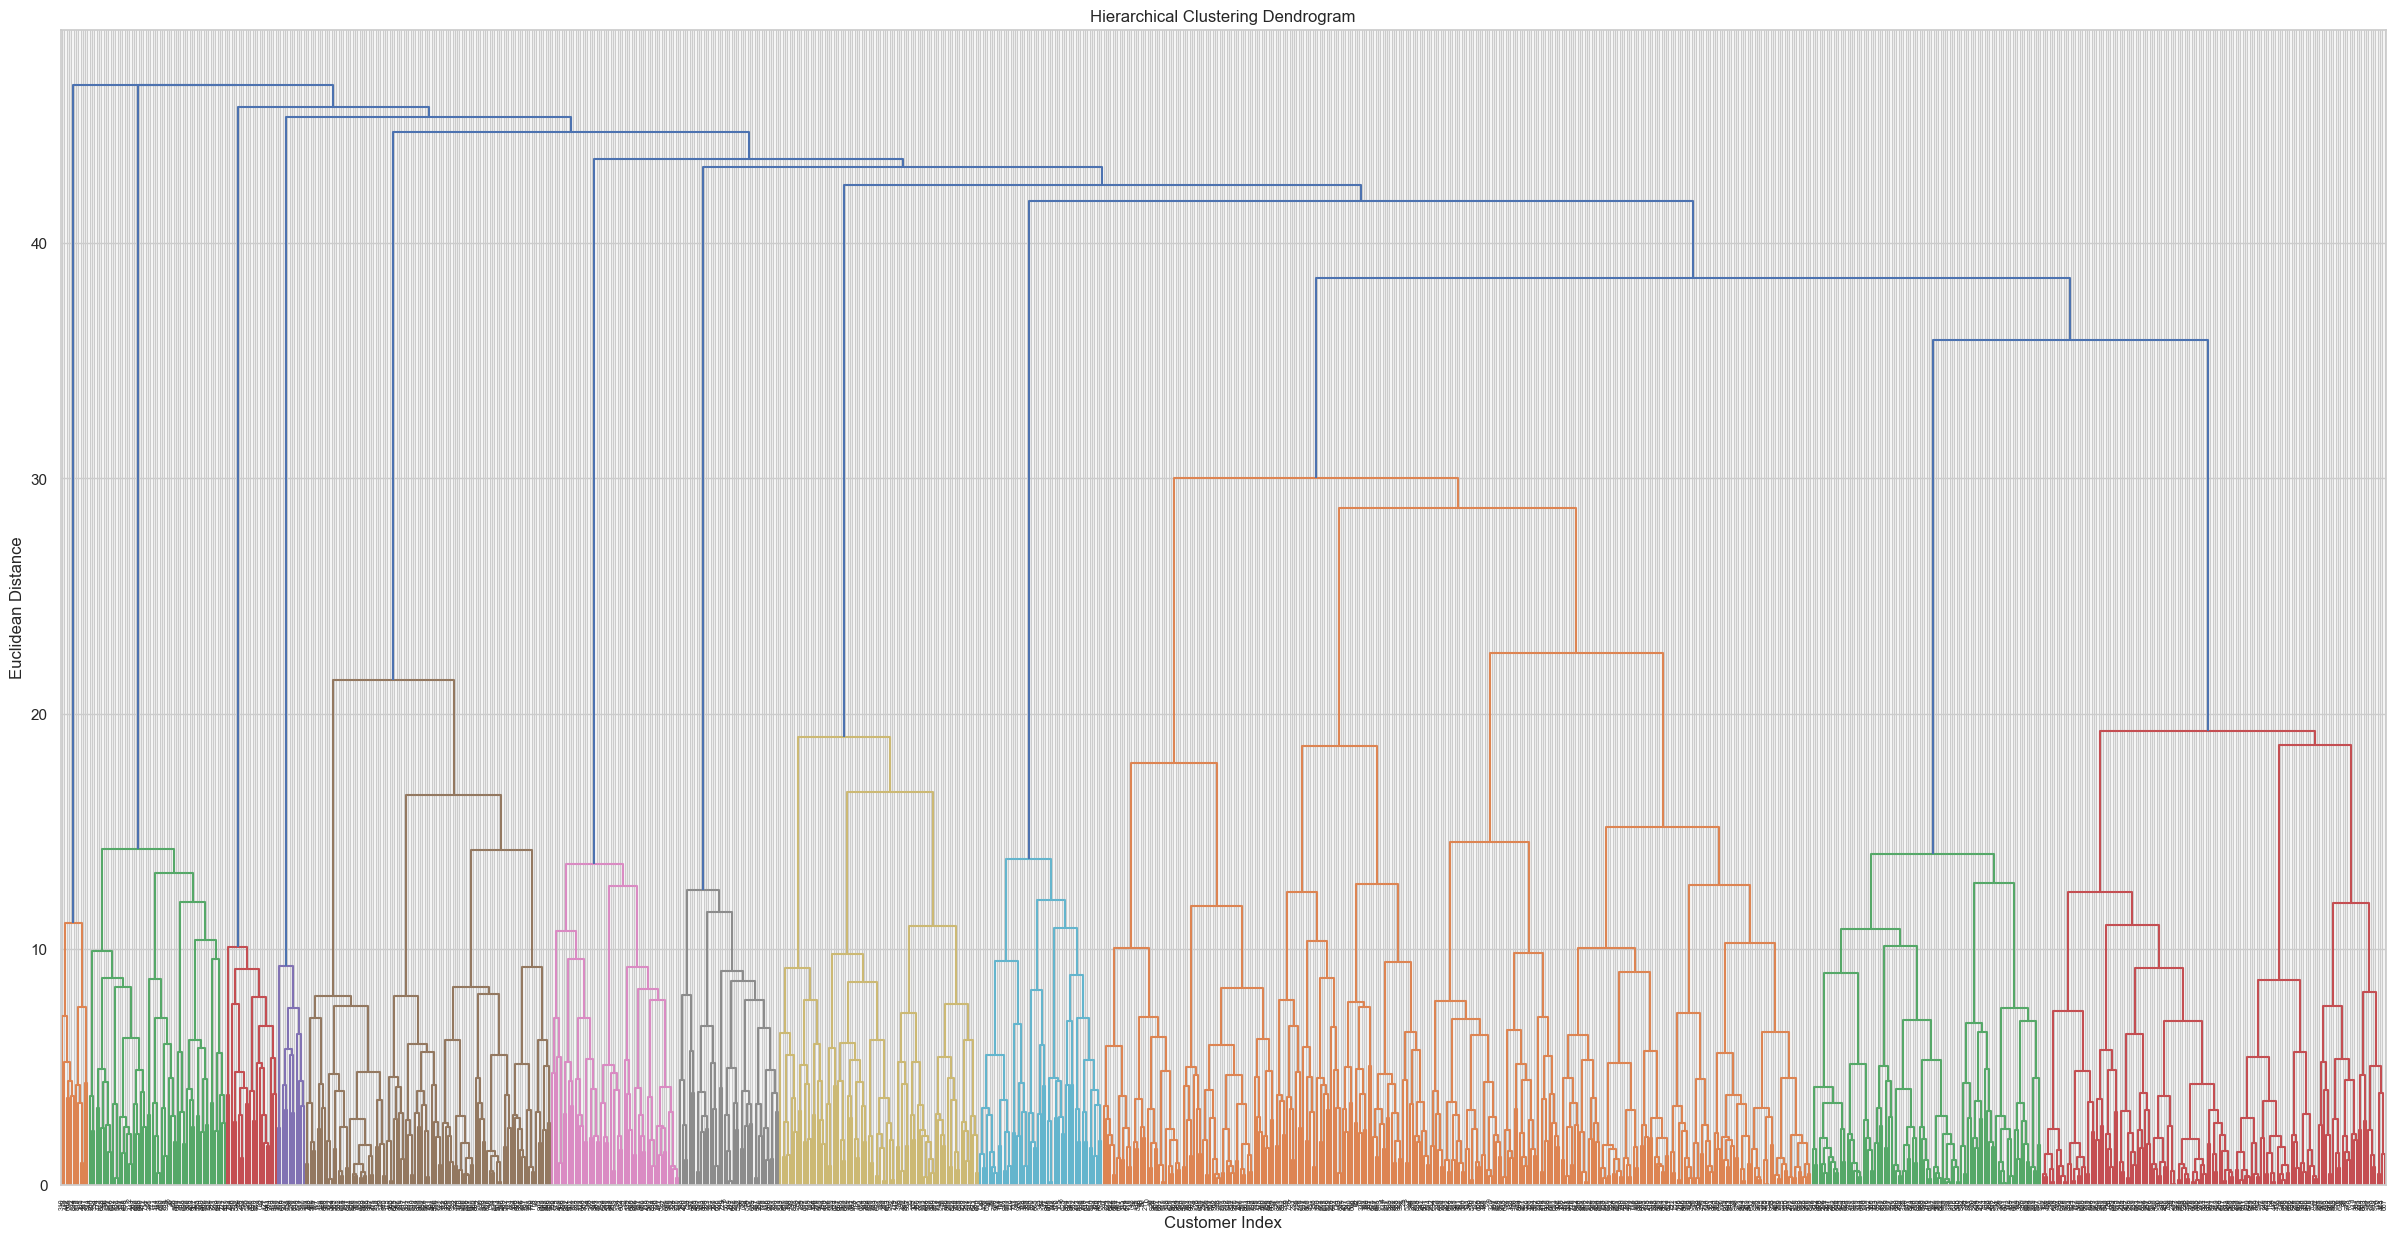

In [36]:
# --- 3. Hierarchical Clustering ---
print("\n#### 3. Hierarchical Clustering (Dendrogram) ####")

plt.figure(figsize=(30, 15))
linkage_matrix = linkage(scaled_features, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()

In [38]:
# --- 4. Finalizing the Clusters ---
# Once you run the above plots, you will see which 'k' is optimal. 
# For the sake of completing the code, we will assume a placeholder k=3, 
# but you should adjust this based on your plot results[cite: 55].

optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# We use the scaled_features from the previous step
cluster_labels = final_kmeans.fit_predict(scaled_features)

# Add the cluster labels back to the original dataframe for analysis
df['Cluster'] = cluster_labels

print(f"### Phase 4: Insights and Interpretation (k={optimal_k}) ###\n")

# --- 2. Analyze the Profile: Numerical Variables ---
# Examine the mean values of each variable per cluster [cite: 69, 70]
numeric_profile = df.groupby('Cluster')[['Age', 'Credit amount', 'Duration', 'Job']].mean()

print("#### Numerical Means per Cluster ####")
print(numeric_profile)

# --- 3. Analyze the Profile: Categorical Variables ---
# Identify the most common (mode) characteristics for each group
print("\n#### Categorical Dominance per Cluster ####")
for i in range(optimal_k):
    print(f"\n--- Cluster {i} Characteristics ---")
    cluster_data = df[df['Cluster'] == i]
    print(f"Top Purpose: {cluster_data['Purpose'].mode()[0]}")
    print(f"Common Housing: {cluster_data['Housing'].mode()[0]}")
    print(f"Checking Account Status: {cluster_data['Checking account'].mode()[0]}")
    print(f"Average Age: {cluster_data['Age'].mean():.1f}")

### Phase 4: Insights and Interpretation (k=3) ###

#### Numerical Means per Cluster ####
               Age  Credit amount   Duration       Job
Cluster                                               
0        36.525237    2162.859621  16.799685  1.801262
1        30.161850    2865.739884  18.346821  1.832370
2        37.155440    7275.813472  36.673575  2.305699

#### Categorical Dominance per Cluster ####

--- Cluster 0 Characteristics ---
Top Purpose: radio/TV
Common Housing: own
Checking Account Status: no_account
Average Age: 36.5

--- Cluster 1 Characteristics ---
Top Purpose: car
Common Housing: rent
Checking Account Status: little
Average Age: 30.2

--- Cluster 2 Characteristics ---
Top Purpose: car
Common Housing: own
Checking Account Status: moderate
Average Age: 37.2


**Cluster 0**: "The Secure Tech Enthusiast" The Profile: This group consists of established individuals in their mid-30s (average age 36.5) who already own their homes.The Behavior: They are seeking relatively small, short-term credit (approx. 2,163 DM over 17 months) specifically for entertainment and lifestyle upgrades like radio and TV.The Narrative: These are stable, lower-risk customers who treat credit as a convenience for lifestyle enhancement rather than a necessity for survival. Since they often don't have a recorded checking account with the bank, messaging should focus on "Easy Entry" loan products and tech-focused promotional bundles.

**Cluster 1**: "The Mobile Aspirant" The Profile: The youngest segment (average age 30.2), these customers are primarily renters with "little" liquidity in their checking accounts.The Behavior: Their primary driver is mobility; they are seeking credit for cars, taking on moderate debt (approx. 2,866 DM) over an 18-month period.The Narrative: This group represents the "Blunt Instrument" of traditional demographic marketing—younger people early in their careers who need transportation to maintain their livelihood. Marketing to them should emphasize low monthly payments and flexible terms that accommodate a renting lifestyle.

**Cluster 2**: "The High-Stake Homeowner" The Profile: These are highly skilled professionals (highest Job score of 2.3) in their late 30s who own their homes and maintain moderate checking balances.The Behavior: They are the "High-Value" outliers, requesting massive credit amounts (approx. 7,276 DM) over very long durations (average 37 months) primarily for cars.The Narrative: This is your most critical segment for revenue. They aren't just buying a car; they are likely investing in high-end vehicles or business-related transport. Because they have the highest Internal Homogeneity in terms of job skill and home ownership, communication should be "Premium" and focus on long-term partnership and high-limit rewards.